# **https://www.kaggle.com/competitions/home-credit-default-risk/data**
# **https://www.kaggle.com/code/carlosdg/xgboost-with-scikit-learn-pipeline-gridsearchcv**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
REPO_DIR="/content/drive/MyDrive/HomeCredit"
%cd $REPO_DIR

/content/drive/MyDrive/HomeCredit


In [ ]:
import sys, os
sys.path.insert(0, os.getcwd())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
df = pd.read_csv("application_train.csv")

In [ ]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.columns.to_list()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [ ]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

/tmp/ipython-input-3869967610.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)


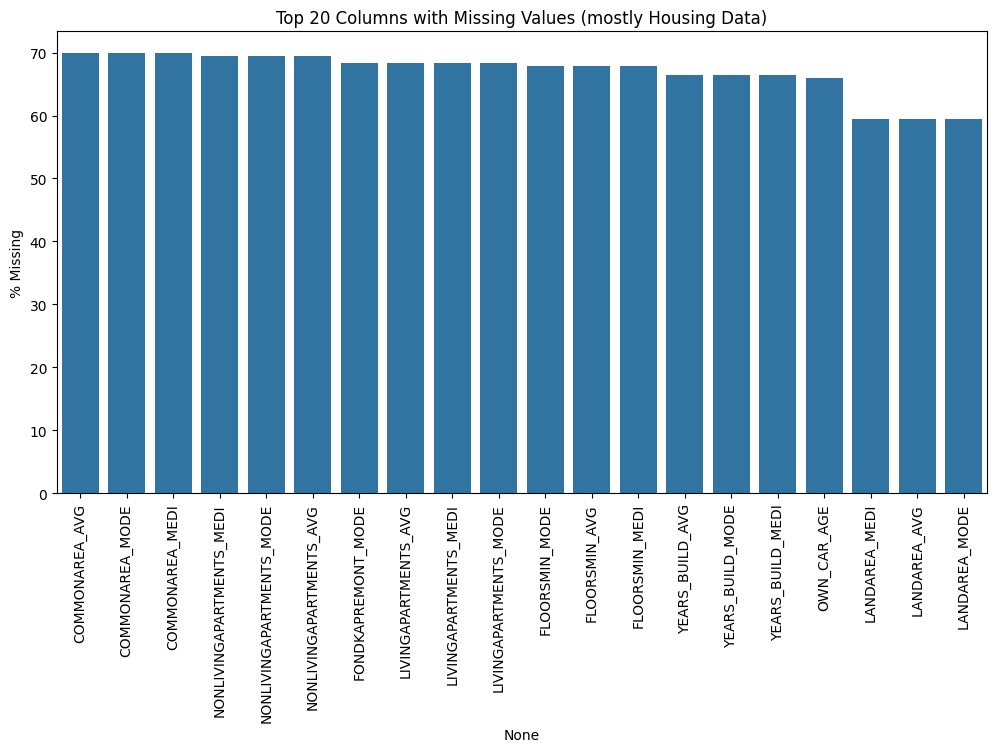

New Features Created:
   CREDIT_INCOME_PERCENT  ANNUITY_INCOME_PERCENT  CREDIT_TERM
0               2.007889                0.121978     0.060749
1               4.790750                0.132217     0.027598
2               2.000000                0.100000     0.050000
3               2.316167                0.219900     0.094941
4               4.222222                0.179963     0.042623


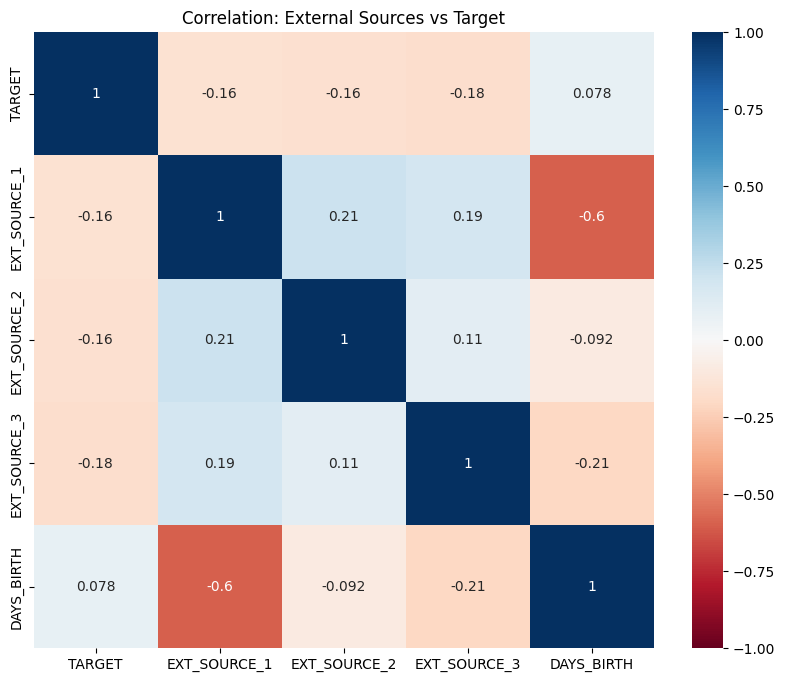

/tmp/ipython-input-3869967610.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='TARGET', data=temp, palette='Reds_d')


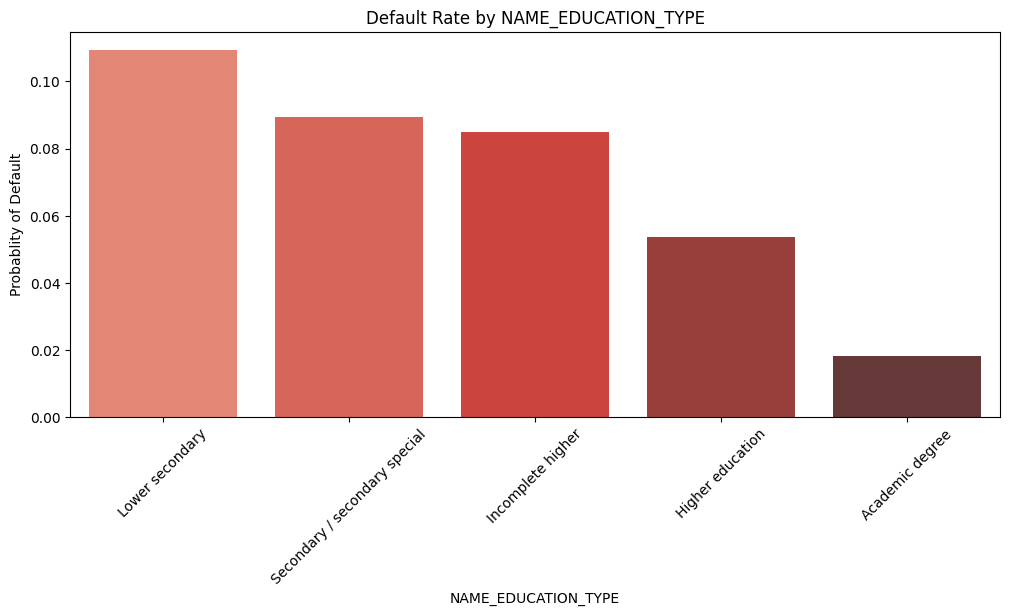

/tmp/ipython-input-3869967610.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='TARGET', data=temp, palette='Reds_d')


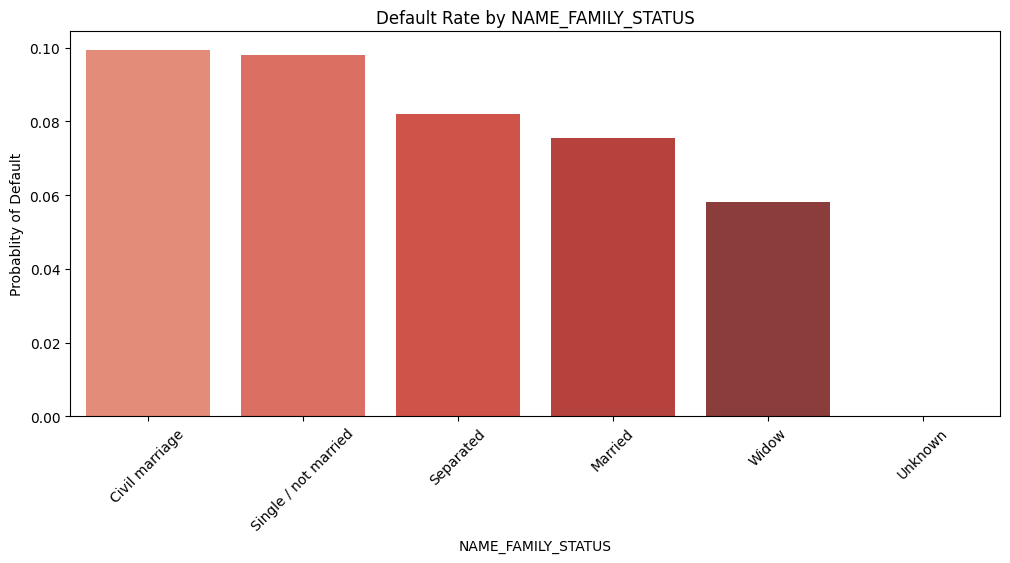

In [ ]:
# FIX: Replace the famous "365243" anomaly in days employed with NaN
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

# 2. The "Missing Data" Audit (Crucial for Housing Columns)
# -------------------------------------------------------
# You have huge blocks of housing data (_AVG, _MODE, _MEDI).
# Let's visualize how much data is actually missing.
def plot_missing_data(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent = (data.isnull().sum() / data.isnull().count() * 100).sort_values(ascending=False)
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

    # Plotting top 20 missing columns
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_data.index[:20], y=missing_data['Percent'][:20])
    plt.xticks(rotation=90)
    plt.title('Top 20 Columns with Missing Values (mostly Housing Data)')
    plt.ylabel('% Missing')
    plt.show()

plot_missing_data(df)

# 3. Domain Knowledge Feature Engineering
# -------------------------------------------------------
# Raw numbers (Income, Credit) are okay, but RATIOS tell the story.
# Here is how to use the 'AMT_...' columns effectively:

# Credit Amount / Total Income: How many years of income is the loan worth?
df['CREDIT_INCOME_PERCENT'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# Annuity / Income: How much of their yearly income goes to paying this specific loan?
df['ANNUITY_INCOME_PERCENT'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Credit Term: Rough estimate of the loan length in years
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

print("New Features Created:")
print(df[['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM']].head())

# 4. Analyzing the "External Sources" (The Gold Mine)
# -------------------------------------------------------
# EXT_SOURCE_1, _2, and _3 are normalized scores from external data providers.
# They are usually the STRONGEST predictors of default. Let's inspect them.

plt.figure(figsize=(10, 8))

# Correlation heatmap of External Sources with Target
ext_data = df[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_corr = ext_data.corr()

sns.heatmap(ext_corr, cmap='RdBu', annot=True, vmin=-1, vmax=1)
plt.title('Correlation: External Sources vs Target')
plt.show()

# 5. Categorical Deep Dive (Education & Family)
# -------------------------------------------------------
# Check if "Family Status" or "Education" impacts Default Risk (TARGET)

def plot_categorical_stats(feature):
    # Calculate default rate per category
    temp = df[[feature, 'TARGET']].groupby([feature], as_index=False).mean()
    temp = temp.sort_values(by='TARGET', ascending=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(x=feature, y='TARGET', data=temp, palette='Reds_d')
    plt.xticks(rotation=45)
    plt.title(f'Default Rate by {feature}')
    plt.ylabel('Probablity of Default')
    plt.show()

plot_categorical_stats('NAME_EDUCATION_TYPE')
plot_categorical_stats('NAME_FAMILY_STATUS')

TARGET
0    282686
1     24825
Name: count, dtype: int64


"EXT_SOURCE_1',\n 'EXT_SOURCE_2',\n 'EXT_SOURCE_3"

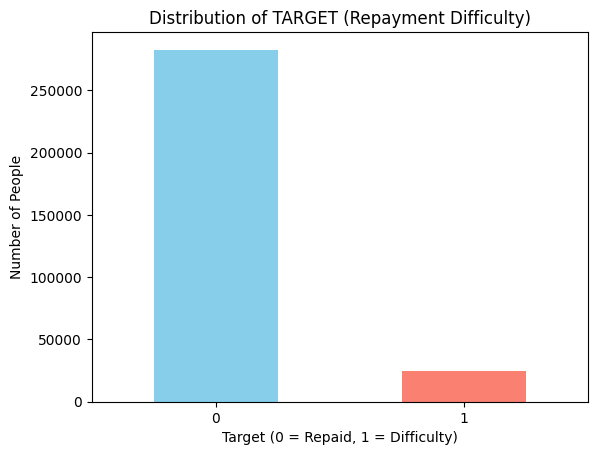

In [ ]:
#pEOPLE EWHO REPAID THEIR LOAN N TIME
counts = df['TARGET'].value_counts().sort_index()
print(counts)

#Plotting the graphs
counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of TARGET (Repayment Difficulty)')
plt.xlabel('Target (0 = Repaid, 1 = Difficulty)')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.savefig('target_distribution.png')


'''EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3'''


<Figure size 800x600 with 0 Axes>

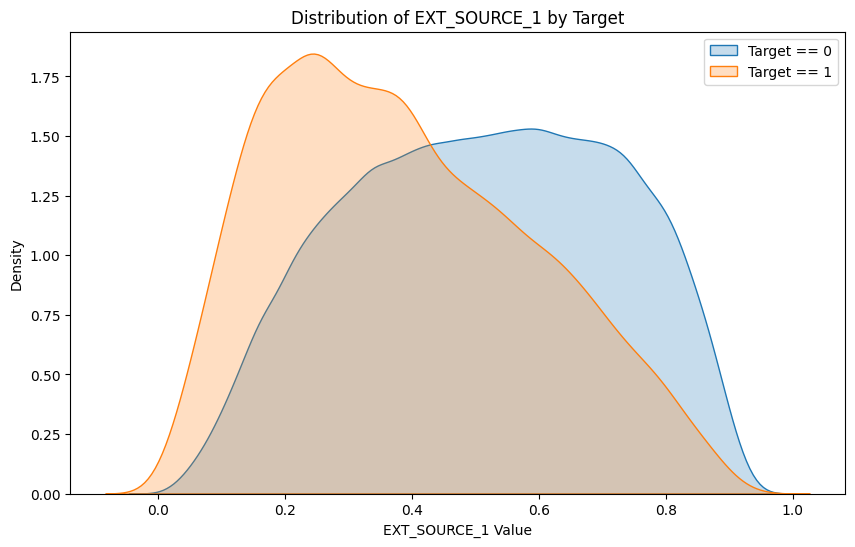

In [ ]:
ext_data = df[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
corr_matrix = ext_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: External Sources vs Target')
plt.savefig('ext_correlation_heatmap.png')
plt.clf()
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['TARGET'] == 0, 'EXT_SOURCE_1'], label='Target == 0', fill=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'EXT_SOURCE_1'], label='Target == 1', fill=True)
plt.title('Distribution of EXT_SOURCE_1 by Target')
plt.xlabel('EXT_SOURCE_1 Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('ext_source_1_distribution.png')

<Figure size 800x600 with 0 Axes>

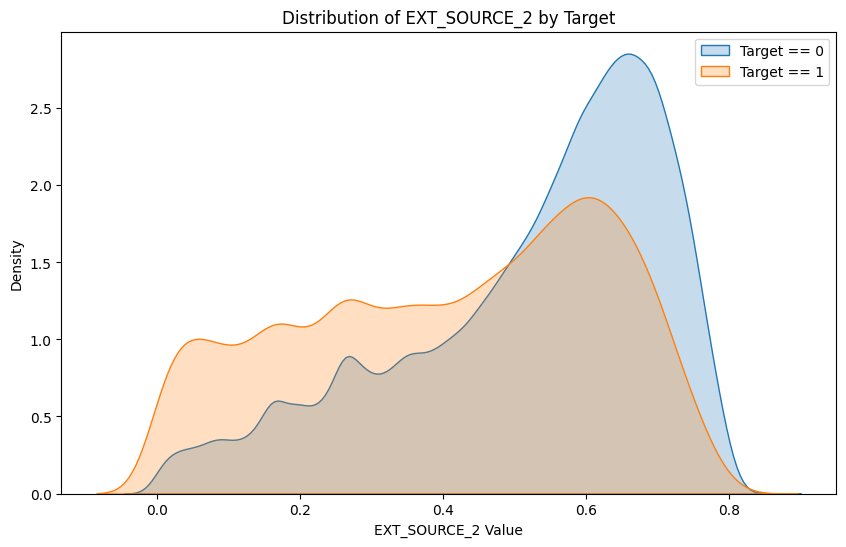

In [ ]:
ext_data = df[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]

# Calculate the correlation matrix
corr_matrix = ext_data.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: External Sources vs Target')
plt.savefig('ext_correlation_heatmap.png')

# This is often very helpful for these specific columns.
plt.clf()
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['TARGET'] == 0, 'EXT_SOURCE_2'], label='Target == 0', fill=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'EXT_SOURCE_2'], label='Target == 1', fill=True)
plt.title('Distribution of EXT_SOURCE_2 by Target')
plt.xlabel('EXT_SOURCE_2 Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('ext_source_2_distribution.png')

<Figure size 800x600 with 0 Axes>

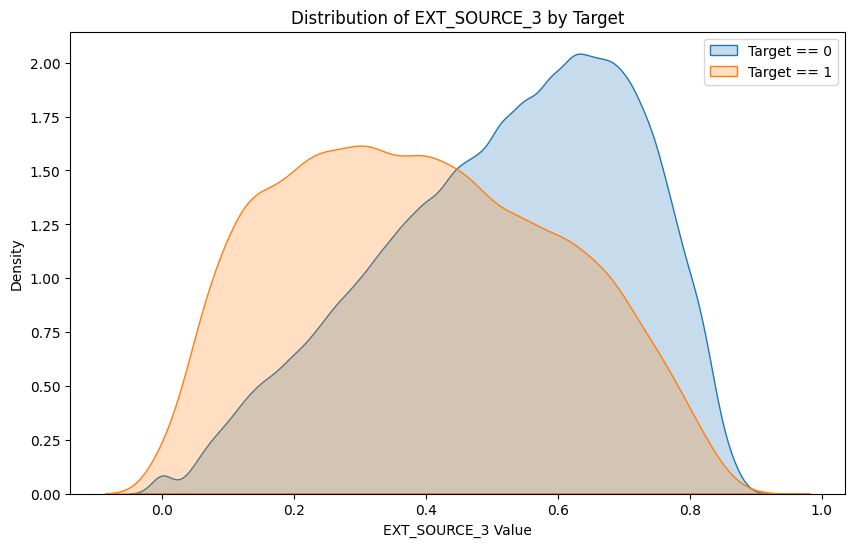

In [ ]:
ext_data = df[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
corr_matrix = ext_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: External Sources vs Target')
plt.savefig('ext_correlation_heatmap.png')
plt.clf()
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['TARGET'] == 0, 'EXT_SOURCE_3'], label='Target == 0', fill=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'EXT_SOURCE_3'], label='Target == 1', fill=True)
plt.title('Distribution of EXT_SOURCE_3 by Target')
plt.xlabel('EXT_SOURCE_3 Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('ext_source_3_distribution.png')

In [ ]:
#checking how many sting type datasets are there
string_columns = df.select_dtypes(include=['object']).columns
print(string_columns)
print(df["NAME_EDUCATION_TYPE"].unique())

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')
['Secondary / secondary special' 'Higher education' 'Incomplete higher'
 'Lower secondary' 'Academic degree']


In [ ]:
edu_map = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
}
# Apply the mapping to your column
df['education_encoded'] = df['NAME_EDUCATION_TYPE'].map(edu_map)

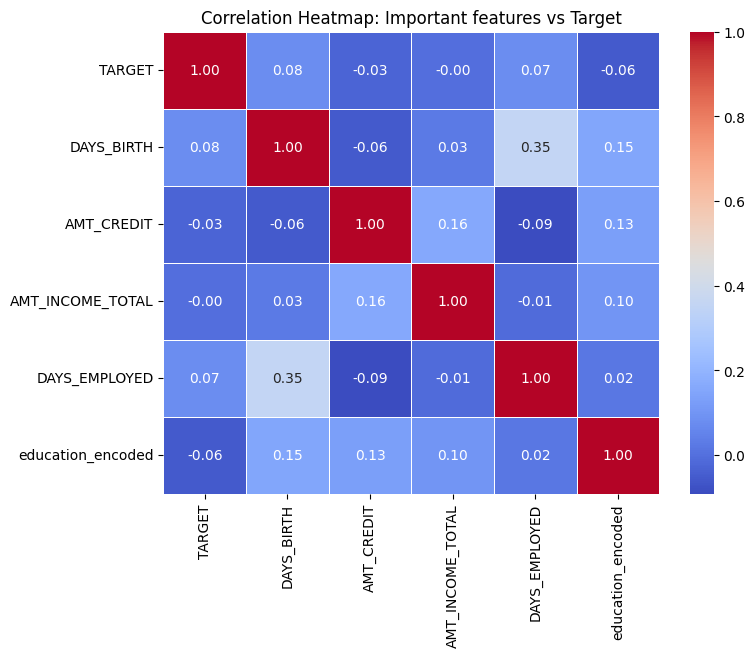

In [ ]:
birth_data= df[['TARGET','DAYS_BIRTH','AMT_CREDIT','AMT_INCOME_TOTAL','DAYS_EMPLOYED','education_encoded']]
corr_matrix = birth_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Important features vs Target')
plt.savefig('birth_correlation_heatmap.png')

<Figure size 640x480 with 0 Axes>

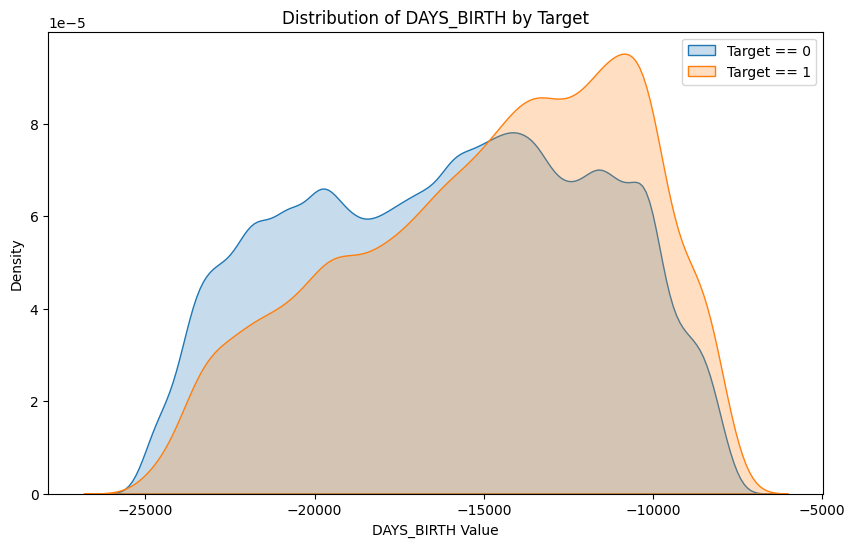

In [ ]:
plt.clf()
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['TARGET'] == 0, 'DAYS_BIRTH'], label='Target == 0', fill=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'DAYS_BIRTH'], label='Target == 1', fill=True)
plt.title('Distribution of DAYS_BIRTH by Target')
plt.xlabel('DAYS_BIRTH Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('BIRTH_distribution.png')

<Figure size 640x480 with 0 Axes>

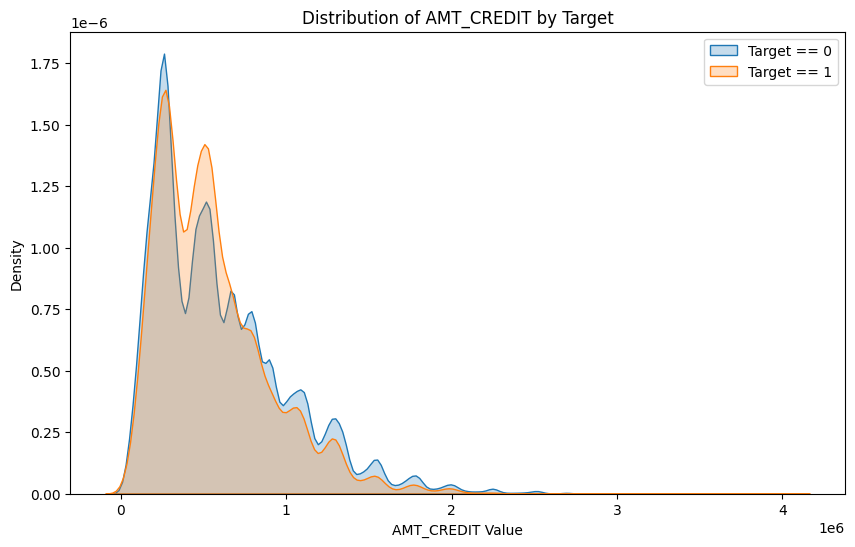

In [ ]:
plt.clf()
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['TARGET'] == 0, 'AMT_CREDIT'], label='Target == 0', fill=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'AMT_CREDIT'], label='Target == 1', fill=True)
plt.title('Distribution of AMT_CREDIT by Target')
plt.xlabel('AMT_CREDIT Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('AMT_distribution.png')

<Figure size 640x480 with 0 Axes>

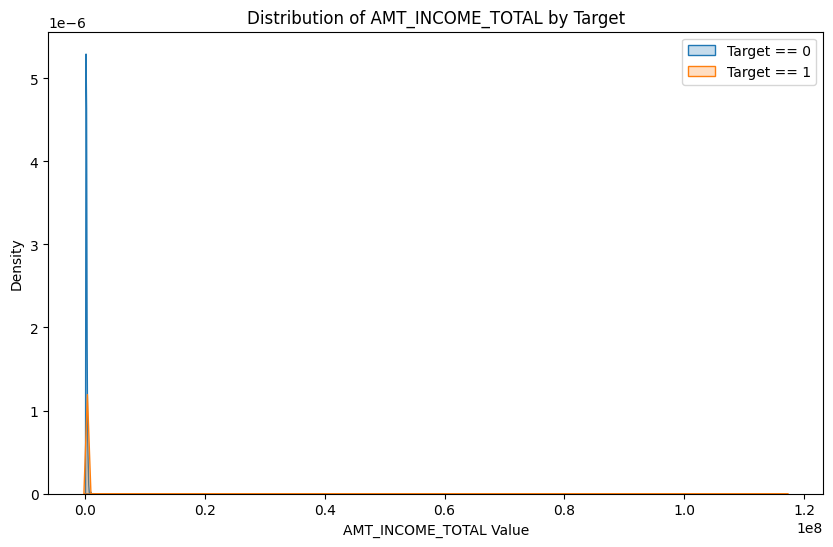

In [ ]:
plt.clf()
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['TARGET'] == 0, 'AMT_INCOME_TOTAL'], label='Target == 0', fill=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'AMT_INCOME_TOTAL'], label='Target == 1', fill=True)
plt.title('Distribution of AMT_INCOME_TOTAL by Target')
plt.xlabel('AMT_INCOME_TOTAL Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('income_distribution.png')

<Figure size 640x480 with 0 Axes>

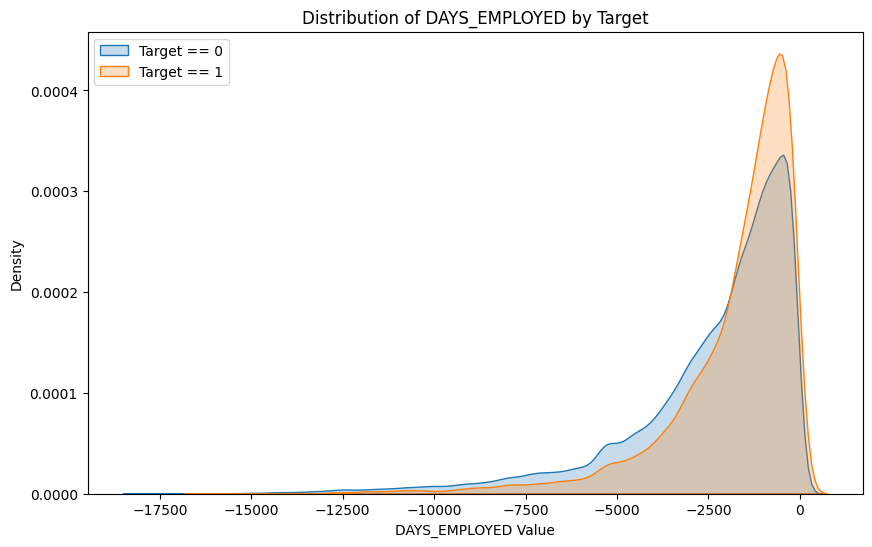

In [ ]:
plt.clf()
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['TARGET'] == 0, 'DAYS_EMPLOYED'], label='Target == 0', fill=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'DAYS_EMPLOYED'], label='Target == 1', fill=True)
plt.title('Distribution of DAYS_EMPLOYED by Target')
plt.xlabel('DAYS_EMPLOYED Value')
plt.ylabel('Density')
plt.legend()
plt.savefig('employed_distribution.png')

In [ ]:
bureau = pd.read_csv('bureau.csv')
merged_app_bur = pd.merge(df,bureau, on='SK_ID_CURR')

In [ ]:
merged_app_bur.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY_x,...,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY_y
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-1038.0,NaN,0,40761.0,NaN,NaN,0.0,Credit card,-1038,0.0
1,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-48.0,NaN,0,0.0,0.0,NaN,0.0,Credit card,-47,NaN
2,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-1185.0,0.000,0,135000.0,0.0,0.0,0.0,Consumer credit,-1185,0.0
3,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-911.0,3321.000,0,19071.0,NaN,NaN,0.0,Consumer credit,-906,0.0
4,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-36.0,5043.645,0,120735.0,0.0,0.0,0.0,Consumer credit,-34,0.0


In [ ]:
print(merged_app_bur.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY_x', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'E

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.342996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12194
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 120
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
                        feature    importance
41                 EXT_SOURCE_3  90585.859381
40                 EXT_SOURCE_2  74666.050864
38            ORGANIZATION_TYPE  36301.013349
122                 CREDIT_TERM  34877.946646
39                 EXT_SOURCE_1  30720.190830
16                DAYS_EMPLOYED  18925.526689
15                   DAYS_BIRTH  15242.162022
18              DAYS_ID_PUBLISH  12079.189565
7                   AMT_

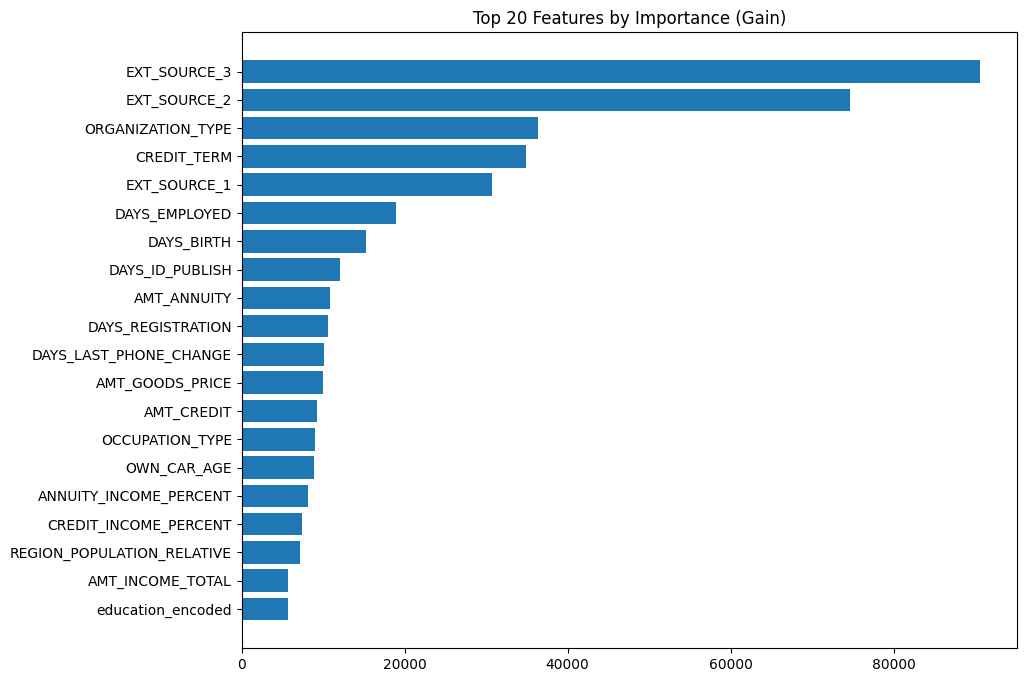

In [ ]:
import lightgbm as lgb
# 1. Prepare Data (Assuming df is your DataFrame)
# Drop IDs and Target from the training set
X = df.drop(columns=['TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU'], errors='ignore')
y = df['TARGET']

# 2. Convert object types to 'category' for LightGBM
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

# 3. Initialize and Fit Model
model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, importance_type='gain')
model.fit(X, y)

# 4. Extract and Plot Importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Show Top 20
print(importance_df.head(20))

# Visualizing
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:20], importance_df['importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Importance (Gain)')
plt.show()

In [ ]:
# 1. Load the Bureau Data
# -------------------------------------------------------
print("Loading Bureau Data...")
print(f"Bureau Shape: {bureau.shape}")

# 2. Feature Engineering (Aggregations)
# -------------------------------------------------------
# We need to squash multiple bureau rows into one row per Client (SK_ID_CURR)

# Group by Client ID and calculate stats
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',                # How many past loans?
    'AMT_CREDIT_SUM': 'sum',                # Total amount of credit they have elsewhere
    'AMT_CREDIT_SUM_DEBT': 'sum',           # Total debt they currently owe elsewhere
    'DAYS_CREDIT': 'mean',                  # Average age of their credit history
    'CREDIT_ACTIVE': lambda x: (x == 'Active').sum() # Count of currently active loans
}).reset_index()

# Rename columns for clarity in the final dataset
bureau_agg.columns = [
    'SK_ID_CURR',
    'BUREAU_LOAN_COUNT',
    'BUREAU_TOTAL_CREDIT',
    'BUREAU_TOTAL_DEBT',
    'BUREAU_AVG_DAYS_CREDIT',
    'BUREAU_ACTIVE_LOANS'
]

print("Aggregated Bureau Data Preview:")
print(bureau_agg.head())

# 3. Merge with Main Application Data
# -------------------------------------------------------
# We assume 'df' is your main application_train dataframe from the previous step
# Perform a Left Join (keep all applicants, add bureau info where it exists)
df=df.merge(bureau_agg, on='SK_ID_CURR',how='left')

# Fill missing values for clients with NO bureau history (fill with 0)
new_cols=['BUREAU_LOAN_COUNT', 'BUREAU_TOTAL_DEBT', 'BUREAU_ACTIVE_LOANS']
df[new_cols] = df[new_cols].fillna(0)

print(f"New Data Shape after Merge: {df.shape}")

# 4. Visualization: Does External Debt Impact Default?
# -------------------------------------------------------
plt.figure(figsize=(10, 6))

# Let's look at the Debt-to-Income Ratio involving OUTSIDE debt
# (We add 1 to avoid division by zero errors)
df['TOTAL_DEBT_RATIO'] = df['BUREAU_TOTAL_DEBT'] / (df['AMT_INCOME_TOTAL'] + 1)

# Plotting the distribution for Defaulters vs. Payers (limiting x-axis for readability)
sns.kdeplot(df.loc[(df['TARGET'] == 0) & (df['TOTAL_DEBT_RATIO'] < 5), 'TOTAL_DEBT_RATIO'], label='Repaid', shade=True)
sns.kdeplot(df.loc[(df['TARGET'] == 1) & (df['TOTAL_DEBT_RATIO'] < 5), 'TOTAL_DEBT_RATIO'], label='Defaulted', shade=True)

plt.title('Impact of External Debt-to-Income Ratio on Default Risk')
plt.xlabel('External Debt / Income')
plt.ylabel('Density')
plt.legend()
plt.show()
plt.savefig('impact_distribution.png')

Loading Bureau Data...


NameError: name 'bureau' is not defined

. The Missing Values Bar Chart (The "Housing Cliff")
What it shows: You have a block of about 20 columns (all related to housing: COMMONAREA, NONLIVINGAPARTMENTS, ELEVATORS, etc.) that are missing ~70% of their data.

What this means for your project:

The Data is Optional: In the real world, this means the loan officers likely didn't require applicants to measure their "basement area" or count their "elevators" to get a loan. Only a small subset of applicants provided this.

Do NOT drop the rows: If you drop rows with missing values, you will lose 70% of your training data.

Do NOT just fill with mean: Filling 70% of a column with the "average" creates a massive amount of fake data that will confuse your model.

Action Item: In your report, recommend creating a "Binary Flag" column (e.g., PROVIDED_HOUSING_INFO = 1 or 0). It is highly likely that the act of providing this detailed information is a signal of honesty or organizational skill, which might correlate with repayment.

2. The Debt-to-Income Density Plot
What it shows: This is a Kernel Density Estimate (KDE) plot. It shows the distribution of the TOTAL_DEBT_RATIO for two groups: those who Repaid (Blue) and those who Defaulted (Orange).

The Tall Spike at 0: This indicates that the vast majority of people (both defaulters and payers) have a Debt-to-Income ratio very close to 0. This likely means many applicants have little to no external debt reported in the bureau file.

The Overlap: The Orange and Blue curves are almost identical in shape. This is a tricky finding. It means that on its own, this specific ratio isn't a "silver bullet" that perfectly separates bad borrowers from good ones.

The "Fat Tails": If you look closely at the base of the spike, you might see the Orange line (Defaulters) drifting slightly wider or higher in the positive direction. This suggests that while most people are similar, the "outliers" with high debt ratios are slightly more likely to be in the Default group.

Action Item: Because the data is so squashed at 0, this feature is hard for a model to learn from in its current state. You should Log Transform this feature to spread out the values, or zoom the graph in to the 0.0 - 2.0 range to see the subtle differences better.

In [ ]:
import os
print(os.getcwd())

/content/drive/MyDrive/HomeCredit


In [ ]:
!ls

AMT_distribution.png	       ext_source_1_distribution.png
application_train.csv	       ext_source_2_distribution.png
birth_correlation_heatmap.png  ext_source_3_distribution.png
BIRTH_distribution.png	       impact_distribution.png
bureau.csv		       income_distribution.png
employed_distribution.png      previous_application.csv
ext_correlation_heatmap.png    target_distribution.png


In [ ]:
prev=pd.read_csv('previous_application.csv')
merged_app_prev=pd.merge(merged_app_bur,prev[:1000], on='SK_ID_CURR')

Loading Previous Applications...
Previous Apps Shape: (1670214, 37)
Aggregating Previous Applications (this may take a moment)...
Aggregated Previous Apps Preview:
            PREV_COUNT  PREV_CNT_APPROVED  PREV_CNT_REFUSED  \
SK_ID_CURR                                                    
100001               1                  1                 0   
100002               1                  1                 0   
100003               3                  3                 0   
100004               1                  1                 0   
100005               2                  1                 0   

            PREV_REFUSAL_RATIO  
SK_ID_CURR                      
100001                     0.0  
100002                     0.0  
100003                     0.0  
100004                     0.0  
100005                     0.0  
Shape before merge: (307511, 132)
Shape after merge: (307511, 142)


/tmp/ipython-input-1285387675.py:73: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['TARGET'] == 0, 'PREV_REFUSAL_RATIO'], label='Repaid (Target=0)', shade=True)
/tmp/ipython-input-1285387675.py:74: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['TARGET'] == 1, 'PREV_REFUSAL_RATIO'], label='Defaulted (Target=1)', shade=True)


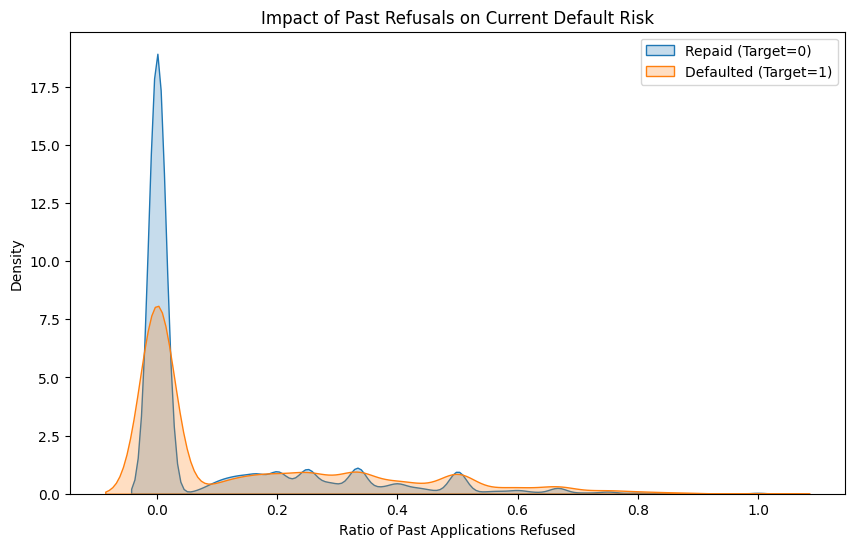

In [ ]:
print("Loading Previous Applications...")
prev_app =pd.read_csv('previous_application.csv')
print(f"Previous Apps Shape: {prev_app.shape}")

# 2. Feature Engineering: Status & Ratios
# -------------------------------------------------------
# Create dummy variables for contract status (Approved, Refused, Canceled, etc.)
# This allows us to count them easily per client
prev_cats = pd.get_dummies(prev_app['NAME_CONTRACT_STATUS'], prefix='PREV')
prev_app = pd.concat([prev_app, prev_cats], axis=1)

# "Price Cut" Ratio: Did they get what they asked for?
# If (Credit / Application) < 1, the bank gave them LESS than requested (Risk signal?)
prev_app['APP_CREDIT_PERC'] = prev_app['AMT_CREDIT'] / prev_app['AMT_APPLICATION']

# 3. Aggregation (Squashing rows per Client)
# -------------------------------------------------------
# We want different stats for different columns:
# - For Status (Approved/Refused): We want the SUM (count of times)
# - For Amounts (Credit/Down Payment): We want the MEAN (average behavior)

agg_dict = {
    # Key Metrics
    'SK_ID_PREV': 'count',           # Total number of previous apps
    'AMT_CREDIT': 'mean',            # Avg credit received
    'AMT_APPLICATION': 'mean',       # Avg credit requested
    'APP_CREDIT_PERC': 'mean',       # Avg "Price Cut" ratio
    'AMT_DOWN_PAYMENT': 'mean',      # Avg down payment made

    # Contract Status Counts (from get_dummies above)
    'PREV_Approved': 'sum',
    'PREV_Refused': 'sum',
    'PREV_Canceled': 'sum',
    'PREV_Unused offer': 'sum'
}

print("Aggregating Previous Applications (this may take a moment)...")
prev_agg = prev_app.groupby('SK_ID_CURR').agg(agg_dict)

# Rename columns to avoid confusion after merge
prev_agg.columns = pd.Index(['PREV_COUNT', 'PREV_AVG_CREDIT', 'PREV_AVG_AMT_APP',
                             'PREV_AVG_CREDIT_PERC', 'PREV_AVG_DOWN_PAYMENT',
                             'PREV_CNT_APPROVED', 'PREV_CNT_REFUSED',
                             'PREV_CNT_CANCELED', 'PREV_CNT_UNUSED'])

# Calculate a "Refusal Ratio" (Refused / Total Apps)
prev_agg['PREV_REFUSAL_RATIO'] = prev_agg['PREV_CNT_REFUSED'] / prev_agg['PREV_COUNT']

print("Aggregated Previous Apps Preview:")
print(prev_agg[['PREV_COUNT', 'PREV_CNT_APPROVED', 'PREV_CNT_REFUSED', 'PREV_REFUSAL_RATIO']].head())

# 4. Merge with Main Data
# -------------------------------------------------------
# Assuming 'df' is your main dataframe from previous steps
print(f"Shape before merge: {df.shape}")
df = df.merge(prev_agg, on='SK_ID_CURR', how='left')

# Fill NaNs for clients with NO previous history
# For counts, fill with 0. For ratios/amounts, fill with 0 or leave as NaN (depending on model choice)
# Here we fill counts with 0 for safety
cols_to_zero = ['PREV_COUNT', 'PREV_CNT_APPROVED', 'PREV_CNT_REFUSED', 'PREV_REFUSAL_RATIO']
df[cols_to_zero] = df[cols_to_zero].fillna(0)

print(f"Shape after merge: {df.shape}")

# 5. Quick Check: Does Refusal History Predict Default?
# -------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Compare Refusal Ratio for Defaulters vs Payers
sns.kdeplot(df.loc[df['TARGET'] == 0, 'PREV_REFUSAL_RATIO'], label='Repaid (Target=0)', shade=True)
sns.kdeplot(df.loc[df['TARGET'] == 1, 'PREV_REFUSAL_RATIO'], label='Defaulted (Target=1)', shade=True)
plt.title('Impact of Past Refusals on Current Default Risk')
plt.xlabel('Ratio of Past Applications Refused')
plt.ylabel('Density')
plt.legend()
plt.show()

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.270896 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14630
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 136
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
                    feature    importance
41             EXT_SOURCE_3  83931.760653
40             EXT_SOURCE_2  71726.099572
38        ORGANIZATION_TYPE  37541.624849
122             CREDIT_TERM  28643.439300
39             EXT_SOURCE_1  28561.755475
16            DAYS_EMPLOYED  15904.460666
127  BUREAU_AVG_DAYS_CREDIT  13221.237378
15               DAYS_BIRTH  12528.422131
133    PREV_AVG_CREDIT_PERC  12225.100573
125     BUREAU_TOT

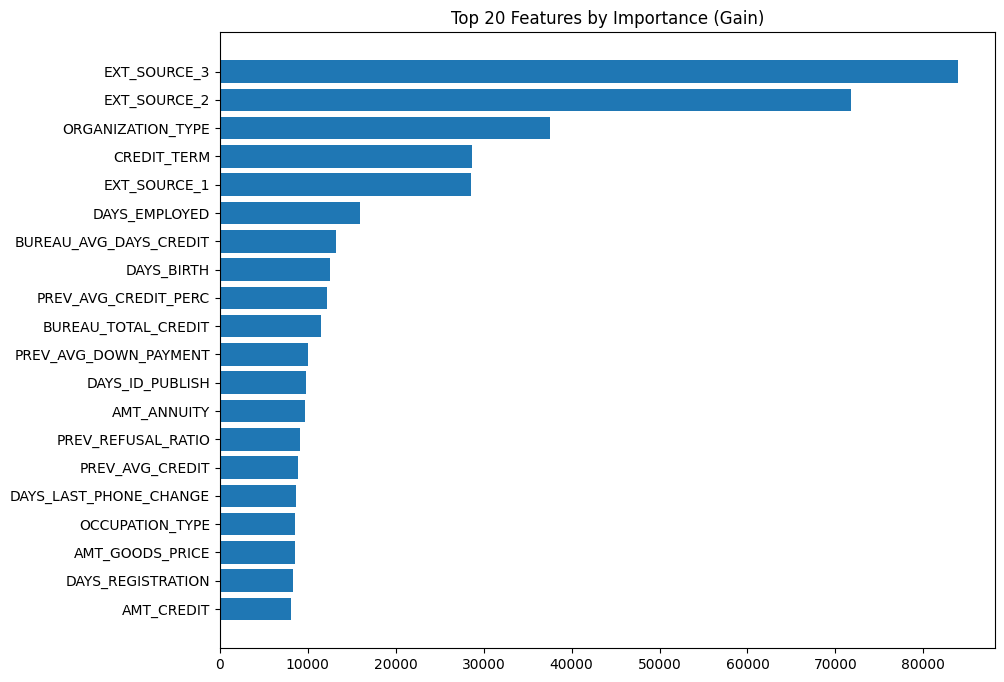

In [ ]:
# 1. Prepare Data (Assuming df is your DataFrame)
# Drop IDs and Target from the training set
X = df.drop(columns=['TARGET', 'SK_ID_CURR', 'SK_ID_BUREAU'], errors='ignore')
y = df['TARGET']

# 2. Convert object types to 'category' for LightGBM
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

# 3. Initialize and Fit Model
model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, importance_type='gain')
model.fit(X, y)

# 4. Extract and Plot Importance
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

# Show Top 20
print(importance_df.head(20))

# Visualizing
plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'][:20], importance_df['importance'][:20])
plt.gca().invert_yaxis()
plt.title('Top 20 Features by Importance (Gain)')
plt.show()

### CLEAN CODE WITH DATA MERGE AND DATA CLEANING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load datasets
# Note: Ensure these files are in your current working directory or specify the path
app_train = pd.read_csv('application_train.csv')
app_test = pd.read_csv('application_test.csv')
bureau = pd.read_csv('bureau.csv')
prev_app = pd.read_csv('previous_application.csv')


# Aggregate Bureau data (Example: count of previous loans)
bureau_counts = bureau.groupby('SK_ID_CURR', as_index=False)['SK_ID_BUREAU'].count().rename(columns={'SK_ID_BUREAU': 'BUREAU_LOAN_COUNT'})

# Aggregate Previous Applications (Example: average previous credit amount)
prev_agg = prev_app.groupby('SK_ID_CURR', as_index=False)['AMT_CREDIT'].agg(['mean']).reset_index()
prev_agg.columns = ['SK_ID_CURR', 'PREV_APP_CREDIT_MEAN']

# Merge into Main Dataframes
def merge_supplementary(df):
    df = df.merge(bureau_counts, on='SK_ID_CURR', how='left')
    df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
    # Fill count NAs with 0
    df['BUREAU_LOAN_COUNT'] = df['BUREAU_LOAN_COUNT'].fillna(0)
    return df

app_train = merge_supplementary(app_train)
app_test = merge_supplementary(app_test)



FileNotFoundError: [Errno 2] No such file or directory: 'application_test.csv'